In [77]:
# Базовые библиотеки для воспроизводимости, анализа и визуализации.
import random
from typing import Dict, List

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import sklearn

import os
import sys
import subprocess

import datasets
import transformers

from datasets import Dataset, DatasetDict, load_dataset
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import train_test_split

from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    DataCollatorWithPadding,
    Trainer,
    TrainingArguments,
    pipeline,
)

pd.set_option("display.max_colwidth", 140)
pd.set_option("display.width", 180)
pd.set_option("display.precision", 4)

print(datasets.__version__)
print(transformers.__version__)
print()


4.8.4
5.4.0



In [78]:
# Фиксируем seed и определяем устройство.
def set_seed(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}")

Device: cpu


In [79]:
import os
from datasets import load_dataset
import pandas as pd

out_dir = "data/emotion"
os.makedirs(out_dir, exist_ok=True)

dataset = load_dataset("emotion")
dataset.save_to_disk(out_dir)

dfs = {split: dataset[split].to_pandas() for split in dataset.keys()}
for split, df in dfs.items():
    print(f"{split}: {len(df)} rows, columns: {list(df.columns)}")

label_col = None
first_split = list(dfs.keys())[0]
for col in dfs[first_split].columns:
    if col in ("label", "labels"):
        label_col = col
        break

label_names = None
if label_col:
    feat = dataset[first_split].features.get(label_col)
    if feat is not None and getattr(feat, "names", None) is not None:
        label_names = list(feat.names)
    elif "train" in dfs:
        label_names = sorted(dfs["train"][label_col].unique().tolist())
    print("label column:", label_col)
    print("label names:", label_names)
    print("id2label:", {i: name for i, name in enumerate(label_names)})
else:
    print("Label column not found")

Saving the dataset (0/1 shards):   0%|          | 0/16000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

Saving the dataset (0/1 shards):   0%|          | 0/2000 [00:00<?, ? examples/s]

train: 16000 rows, columns: ['text', 'label']
validation: 2000 rows, columns: ['text', 'label']
test: 2000 rows, columns: ['text', 'label']
label column: label
label names: ['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [80]:
splits = list(dataset.keys())
dfs = {split: dataset[split].to_pandas() for split in splits}
if len(dfs) > 1:
    df = pd.concat(dfs.values(), ignore_index=True)
else:
    df = next(iter(dfs.values()))

train_df = dfs.get("train")
val_df = dfs.get("validation") if dfs.get("validation") is not None else dfs.get("val")
test_df = dfs.get("test")

print("all splits:", splits)
print("df:", df.shape)
print("train_df:", None if train_df is None else train_df.shape)
print("val_df:", None if val_df is None else val_df.shape)
print("test_df:", None if test_df is None else test_df.shape)

all splits: ['train', 'validation', 'test']
df: (20000, 2)
train_df: (16000, 2)
val_df: (2000, 2)
test_df: (2000, 2)


In [81]:
display(df.head())

,text,label
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake,0
2,im grabbing a minute to post i feel greedy wrong,3
3,i am ever feeling nostalgic about the fireplace i will know that it is still on the property,2
4,i am feeling grouchy,3


In [82]:
display(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20000 entries, 0 to 19999
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype 
---  ------  --------------  ----- 
 0   text    20000 non-null  object
 1   label   20000 non-null  int64 
dtypes: int64(1), object(1)
memory usage: 312.6+ KB


None

In [83]:
display(df.describe())

,label
count,20000.0000
mean,1.5629
std,1.4967
min,0.0000
25%,0.0000
50%,1.0000
75%,3.0000
max,5.0000


In [84]:
# Смотрим размер датасета и распределение по классам.
print("Размер датасета:", len(df))
display(df["label"].value_counts())

# label_names = sorted(df["label"].unique())
label2id = {i: name for i, name in enumerate(label_names)}
id2label = {name: i for i, name in enumerate(label_names)}

df["label_id"] = df["label"].map(label2id)

print(label_names)
print("label2id:", label2id)
print("id2label:", id2label)

display(df.sample(6, random_state=42).reset_index(drop=True))


Размер датасета: 20000


label
1    6761
0    5797
3    2709
4    2373
2    1641
5     719
Name: count, dtype: int64

['sadness', 'joy', 'love', 'anger', 'fear', 'surprise']
label2id: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}
id2label: {'sadness': 0, 'joy': 1, 'love': 2, 'anger': 3, 'fear': 4, 'surprise': 5}


,text,label,label_id
0,i noticed several months ago that i d start feeling resentful as i walked toward a pedestrian crossing with the intention of course of c...,3,anger
1,i love lots of different kinds of sports and love hanging out with my friends in my free time i also have an unhealthy up session with g...,1,joy
2,i feel even if he killed himself it was because he was agonized to that extent,0,sadness
3,i feel numb the way a wound does before it really starts to hurt,0,sadness
4,i feel very happy to have inspired is my little sis love of reading and writing,1,joy
5,i began to feel unimportant useless insecure and i was disconnected from everything that i used to know,0,sadness


В наборе emotion классифицируются короткие тексты на английском по одной из шести эмоций — anger, fear, joy, love, sadness, surprise.

In [85]:
# print(AutoTokenizer)
# print(callable(AutoTokenizer.from_pretrained))
# import inspect
# print(AutoTokenizer.from_pretrained)
# try:
#     print(inspect.getsource(AutoTokenizer.from_pretrained))
# except Exception as e:
#     print("inspect failed:", e)

In [86]:
# from transformers import AutoTokenizer, BertTokenizerFast
# MODEL_NAME = "bert-base-multilingual-cased"
#
# # 1) Проверка AutoTokenizer
# try:
#     tok = AutoTokenizer.from_pretrained(MODEL_NAME)
#     print("AutoTokenizer returned:", type(tok))
#     print("vocab_size:", getattr(tok, "vocab_size", None))
#     print("is_fast:", getattr(tok, "is_fast", None))
# except Exception as e:
#     import traceback
#     print("AutoTokenizer raised:")
#     traceback.print_exc()
#
# # 2) Явная загрузка конкретного класса
# try:
#     tok2 = BertTokenizerFast.from_pretrained(MODEL_NAME)
#     print("BertTokenizerFast returned:", type(tok2))
#     print("vocab_size:", getattr(tok2, "vocab_size", None))
# except Exception as e:
#     import traceback
#     print("BertTokenizerFast raised:")
#     traceback.print_exc()

In [87]:
MODEL_NAME = "distilbert-base-uncased"
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

In [88]:
texts = df["text"].head().tolist()

batch_no_trunc = tokenizer(
    texts,
    padding=True,
    return_tensors="pt",
)

batch_with_trunc = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors="pt",
)

print("Без truncation:")
print("input_ids shape:", tuple(batch_no_trunc["input_ids"].shape))
print("attention_mask shape:", tuple(batch_no_trunc["attention_mask"].shape))
print()

print("С truncation и max_length=32:")
print("input_ids shape:", tuple(batch_with_trunc["input_ids"].shape))
print("attention_mask shape:", tuple(batch_with_trunc["attention_mask"].shape))
print()

# short_text = df["text"].iloc[0]
# long_text = df["text"].iloc[df["text"].str.len().idxmax()]

batch_pair = tokenizer(
    texts,
    padding=True,
    truncation=True,
    max_length=32,
    return_tensors="pt",
)

for idx, text in enumerate(texts):
    print(f"--- Пример {idx+1} ---")
    print("Исходный текст:", text)
    print("Токены после truncation:")
    print(tokenizer.convert_ids_to_tokens(batch_pair["input_ids"][idx].tolist()))
    print("attention_mask:")
    print(batch_pair["attention_mask"][idx].tolist())
    print()

pad_ids = batch_no_trunc["input_ids"][0].tolist()
pad_tokens = tokenizer.convert_ids_to_tokens(pad_ids)
pad_mask = batch_no_trunc["attention_mask"][0].tolist()

display(
    pd.DataFrame(
        {
            "position": list(range(len(pad_ids))),
            "token": pad_tokens,
            "token_id": pad_ids,
            "attention_mask": pad_mask,
        }
    )
)

Без truncation:
input_ids shape: (5, 23)
attention_mask shape: (5, 23)

С truncation и max_length=32:
input_ids shape: (5, 23)
attention_mask shape: (5, 23)

--- Пример 1 ---
Исходный текст: i didnt feel humiliated
Токены после truncation:
['[CLS]', 'i', 'didn', '##t', 'feel', 'humiliated', '[SEP]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]', '[PAD]']
attention_mask:
[1, 1, 1, 1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0]

--- Пример 2 ---
Исходный текст: i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake
Токены после truncation:
['[CLS]', 'i', 'can', 'go', 'from', 'feeling', 'so', 'hopeless', 'to', 'so', 'damned', 'hopeful', 'just', 'from', 'being', 'around', 'someone', 'who', 'cares', 'and', 'is', 'awake', '[SEP]']
attention_mask:
[1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]

--- Пример 3 ---
Исходн

,position,token,token_id,attention_mask
0,0,[CLS],101,1
1,1,i,1045,1
2,2,didn,2134,1
3,3,##t,2102,1
4,4,feel,2514,1
5,5,humiliated,26608,1
6,6,[SEP],102,1
7,7,[PAD],0,0
8,8,[PAD],0,0
9,9,[PAD],0,0


In [89]:
if "label_names" not in globals():
    label_vals = sorted(train_df["label"].unique().tolist())
    label_names = [str(x) for x in label_vals]

id2label = {int(i): str(name) for i, name in enumerate(label_names)}
label2id = {str(name): int(i) for i, name in enumerate(label_names)}

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_names),
    id2label=id2label,
    label2id=label2id,
    ignore_mismatched_sizes=True,
)

model.to(device)
model.eval()

print("Model class:", model.__class__.__name__)
print("Number of labels:", model.config.num_labels)
print("id2label:", model.config.id2label)

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
pre_classifier.weight   | MISSING    | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Model class: DistilBertForSequenceClassification
Number of labels: 6
id2label: {0: 'sadness', 1: 'joy', 2: 'love', 3: 'anger', 4: 'fear', 5: 'surprise'}


In [90]:
demo_texts = [
    "This course turned out to be very useful, the explanations are clear and the examples are well chosen.",
    "Complete failure: the application freezes, data gets lost, impossible to use.",
    "Overall okay, but the documentation is confusing in places and there are too few examples.",
    "The interface is clean, everything works fast, I am satisfied with the result.",
    "Expected more: the idea is good, but the implementation is raw and unstable.",
    "The model successfully processed the request and returned a response without errors.",
    "The service formally completed the task, however the process took too much time.",
    "I can't say the product is bad, but it didn't impress me either.",
]

pd.DataFrame({"text": demo_texts})

,text
0,"This course turned out to be very useful, the explanations are clear and the examples are well chosen."
1,"Complete failure: the application freezes, data gets lost, impossible to use."
2,"Overall okay, but the documentation is confusing in places and there are too few examples."
3,"The interface is clean, everything works fast, I am satisfied with the result."
4,"Expected more: the idea is good, but the implementation is raw and unstable."
5,The model successfully processed the request and returned a response without errors.
6,"The service formally completed the task, however the process took too much time."
7,"I can't say the product is bad, but it didn't impress me either."


In [91]:
pipeline_device = 0 if torch.cuda.is_available() else -1

In [92]:
# Создаём high-level pipeline для классификации текста.
text_clf = pipeline(
    task="text-classification",
    model=model,
    tokenizer=tokenizer,
    device=pipeline_device,
)

pipeline_outputs = text_clf(test_df["text"].head().tolist())

pipeline_df = pd.DataFrame(
    {
        "text": test_df["text"].head().tolist(),
        "predicted_label": [item["label"] for item in pipeline_outputs],
        "score": [item["score"] for item in pipeline_outputs],
    }
)

pipeline_df

,text,predicted_label,score
0,im feeling rather rotten so im not very ambitious right now,anger,0.1796
1,im updating my blog because i feel shitty,anger,0.1835
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,anger,0.1826
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,anger,0.1824
4,i was feeling a little vain when i did this one,anger,0.1833


Такая готовая модель подходит под выбранную задачу классификации эмоций, но он не специализирован под эмоции и требует дообучения и учёта особенностей данных.

In [93]:
# Приводим датафреймы к формату HuggingFace Dataset.
train_ds = Dataset.from_pandas(
    train_df[["text", "label"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
val_ds = Dataset.from_pandas(
    val_df[["text", "label"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)
test_ds = Dataset.from_pandas(
    test_df[["text", "label"]].rename(columns={"label_id": "labels"}).reset_index(drop=True),
    preserve_index=False,
)

dataset_dict = DatasetDict({
    "train": train_ds,
    "validation": val_ds,
    "test": test_ds,
})

dataset_dict


DatasetDict({
    train: Dataset({
        features: ['text', 'label'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['text', 'label'],
        num_rows: 2000
    })
})

In [94]:
def tokenize_batch(batch: Dict[str, List[str]]) -> Dict[str, List[List[int]]]:
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=128,
    )

tokenized_datasets = dataset_dict.map(tokenize_batch, batched=True)

# Удаляем столбец "text": DataCollatorWithPadding попытается преобразовать
# все поля датасета в тензоры, а строки в тензор не конвертируются.
tokenized_datasets = tokenized_datasets.remove_columns(["text"])
tokenized_datasets

Map:   0%|          | 0/16000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

Map:   0%|          | 0/2000 [00:00<?, ? examples/s]

DatasetDict({
    train: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 16000
    })
    validation: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
    test: Dataset({
        features: ['label', 'input_ids', 'token_type_ids', 'attention_mask'],
        num_rows: 2000
    })
})

In [95]:
# Data collator будет добавлять padding динамически, прямо при формировании батча.
data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

sample_batch = [tokenized_datasets["train"][i] for i in range(3)]
collated_batch = data_collator(sample_batch)

for key, value in collated_batch.items():
    print(f"{key}: shape={tuple(value.shape)}")


input_ids: shape=(3, 23)
token_type_ids: shape=(3, 23)
attention_mask: shape=(3, 23)
labels: shape=(3,)


In [96]:
# Функция метрик для Trainer.
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)

    acc = accuracy_score(labels, preds)
    f1_macro = f1_score(labels, preds, average="macro")
    f1_weighted = f1_score(labels, preds, average="weighted")

    return {
        "accuracy": acc,
        "f1_macro": f1_macro,
        "f1_weighted": f1_weighted,
    }


In [97]:
# Общие параметры обучения.
common_training_kwargs = dict(
    output_dir="outputs/s13_bert_finetuning",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    logging_steps=2,
    save_total_limit=1,
    load_best_model_at_end=True,
    metric_for_best_model="f1_macro",
    greater_is_better=True,
    report_to="none",
)

try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

training_args


TrainingArguments(
accelerator_config={'split_batches': False, 'dispatch_batches': None, 'even_batches': True, 'use_seedable_sampler': True, 'non_blocking': False, 'gradient_accumulation_kwargs': None, 'use_configured_state': False},
adam_beta1=0.9,
adam_beta2=0.999,
adam_epsilon=1e-08,
auto_find_batch_size=False,
average_tokens_across_devices=True,
batch_eval_metrics=False,
bf16=False,
bf16_full_eval=False,
data_seed=None,
dataloader_drop_last=False,
dataloader_num_workers=0,
dataloader_persistent_workers=False,
dataloader_pin_memory=True,
dataloader_prefetch_factor=None,
ddp_backend=None,
ddp_broadcast_buffers=None,
ddp_bucket_cap_mb=None,
ddp_find_unused_parameters=None,
ddp_timeout=1800,
debug=[],
deepspeed=None,
disable_tqdm=False,
do_eval=True,
do_predict=False,
do_train=False,
enable_jit_checkpoint=False,
eval_accumulation_steps=None,
eval_delay=0,
eval_do_concat_batches=True,
eval_on_start=False,
eval_steps=None,
eval_strategy=IntervalStrategy.EPOCH,
eval_use_gather_object=Fals

In [98]:
subset_size = 1000


small_train = tokenized_datasets["train"].select(range(min(subset_size, len(tokenized_datasets["train"]))))
print("Using", len(small_train), "examples for training per epoch")



try:
    training_args = TrainingArguments(
        evaluation_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )
except TypeError:
    training_args = TrainingArguments(
        eval_strategy="epoch",
        save_strategy="epoch",
        **common_training_kwargs,
    )

try:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=small_train,
        eval_dataset=tokenized_datasets.get("validation") or tokenized_datasets.get("val"),
        processing_class=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )
except TypeError:
    trainer = Trainer(
        model=model,
        args=training_args,
        train_dataset=small_train,
        eval_dataset=tokenized_datasets.get("validation") or tokenized_datasets.get("val"),
        tokenizer=tokenizer,
        data_collator=data_collator,
        compute_metrics=compute_metrics,
    )

train_result = trainer.train()
print(train_result)

Using 1000 examples for training per epoch


C:\Users\valentin\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Accuracy,F1 Macro,F1 Weighted
1,1.297019,1.163429,0.574000,0.234856,0.447879
2,0.877377,0.864350,0.712500,0.485290,0.657667
3,0.644984,0.763443,0.753500,0.573247,0.720759


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\valentin\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

C:\Users\valentin\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.weight', 'distilbert.embeddings.LayerNorm.bias'].
There were unexpected keys in the checkpoint model loaded: ['distilbert.embeddings.LayerNorm.beta', 'distilbert.embeddings.LayerNorm.gamma'].


TrainOutput(global_step=375, training_loss=1.0935745787620545, metrics={'train_runtime': 403.5388, 'train_samples_per_second': 7.434, 'train_steps_per_second': 0.929, 'total_flos': 32773530256416.0, 'train_loss': 1.0935745787620545, 'epoch': 3.0})


,loss,grad_norm,learning_rate,epoch,step,eval_loss,eval_accuracy,eval_f1_macro,eval_f1_weighted,eval_runtime,eval_samples_per_second,eval_steps_per_second,train_runtime,train_samples_per_second,train_steps_per_second,total_flos,train_loss
0,1.7977,3.2737,1.9947e-05,0.016,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1.7462,3.2957,1.9840e-05,0.032,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,1.7657,2.8763,1.9733e-05,0.048,6,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,1.7400,4.0016,1.9627e-05,0.064,8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,1.7431,2.4952,1.9520e-05,0.080,10,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
5,1.7097,3.0319,1.9413e-05,0.096,12,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6,1.6636,2.8512,1.9307e-05,0.112,14,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7,1.6527,3.2122,1.9200e-05,0.128,16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
8,1.7292,4.9315,1.9093e-05,0.144,18,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,1.6015,3.4049,1.8987e-05,0.160,20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


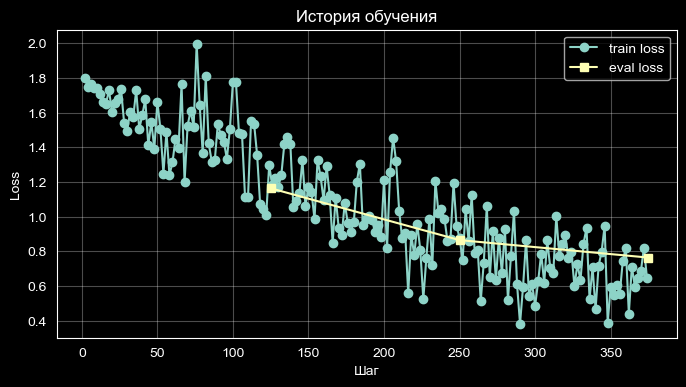

In [99]:
# История логов Trainer.
history_df = pd.DataFrame(trainer.state.log_history)
display(history_df.head(10))

plt.figure(figsize=(8, 4))

if "loss" in history_df.columns:
    train_logs = history_df.dropna(subset=["loss"])
    plt.plot(train_logs["step"], train_logs["loss"], marker="o", label="train loss")

if "eval_loss" in history_df.columns:
    eval_logs = history_df.dropna(subset=["eval_loss"])
    plt.plot(eval_logs["step"], eval_logs["eval_loss"], marker="s", label="eval loss")

plt.title("История обучения")
plt.xlabel("Шаг")
plt.ylabel("Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()


In [100]:
# В transformers >= 5.x NotebookProgressCallback теряет состояние после обучения,
# что вызывает RuntimeError при вызове evaluate() вне тренировочного цикла.
# Удаляем его перед standalone-оценкой – это стандартный обходной путь.
from transformers.utils.notebook import NotebookProgressCallback
trainer.remove_callback(NotebookProgressCallback)

# Оценка Trainer на validation и test.
val_metrics = trainer.evaluate(tokenized_datasets["validation"])
test_metrics = trainer.evaluate(tokenized_datasets["test"])

print("Validation metrics:")
for k, v in val_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")

print("\nTest metrics:")
for k, v in test_metrics.items():
    print(f"{k}: {v:.4f}" if isinstance(v, (int, float)) else f"{k}: {v}")


C:\Users\valentin\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
C:\Users\valentin\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Validation metrics:
eval_loss: 0.7634
eval_accuracy: 0.7535
eval_f1_macro: 0.5732
eval_f1_weighted: 0.7208
eval_runtime: 40.4909
eval_samples_per_second: 49.3940
eval_steps_per_second: 6.1740
epoch: 3.0000

Test metrics:
eval_loss: 0.7327
eval_accuracy: 0.7740
eval_f1_macro: 0.5615
eval_f1_weighted: 0.7391
eval_runtime: 39.9338
eval_samples_per_second: 50.0830
eval_steps_per_second: 6.2600
epoch: 3.0000


C:\Users\valentin\AppData\Roaming\Python\Python313\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Classification report on test:
              precision    recall  f1-score   support

     sadness       0.75      0.92      0.83       581
         joy       0.80      0.95      0.87       695
        love       0.69      0.15      0.25       159
       anger       0.79      0.63      0.70       275
        fear       0.74      0.72      0.73       224
    surprise       0.00      0.00      0.00        66

    accuracy                           0.77      2000
   macro avg       0.63      0.56      0.56      2000
weighted avg       0.74      0.77      0.74      2000



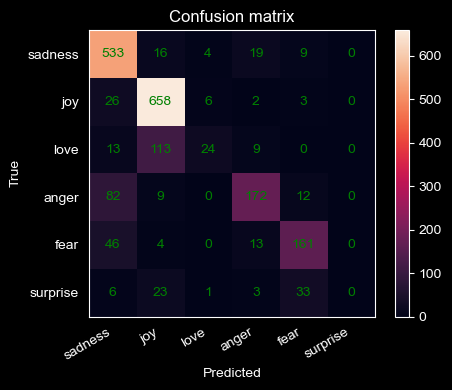

In [101]:
# Детальные предсказания на тестовой выборке.
test_output = trainer.predict(tokenized_datasets["test"])
test_logits = test_output.predictions
test_preds = np.argmax(test_logits, axis=-1)
test_true = test_output.label_ids

print("Classification report on test:")
print(
    classification_report(
        test_true,
        test_preds,
        target_names=[id2label[i] for i in range(len(id2label))],
        zero_division=0,
    )
)

cm = confusion_matrix(test_true, test_preds)

fig, ax = plt.subplots(figsize=(5, 4))
im = ax.imshow(cm)

ax.set_xticks(range(len(label_names)))
ax.set_yticks(range(len(label_names)))
ax.set_xticklabels(label_names, rotation=30, ha="right")
ax.set_yticklabels(label_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
ax.set_title("Confusion matrix")

ax.grid(False)

for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        ax.text(j, i, cm[i, j], ha="center", va="center", color="green")

plt.colorbar(im, ax=ax)
plt.tight_layout()
plt.savefig("artifacts/confusion_matrix.png")
plt.show()


In [103]:
texts = test_df["text"].head(n=10).tolist()

# display(test_df["text"].head().tolist())
# Вспомогательная функция для инференса новых текстов.
def predict_texts() -> pd.DataFrame:
    encoded = tokenizer(
        texts,
        return_tensors="pt",
        padding=True,
        truncation=True,
        max_length=128,
    )
    encoded = {k: v.to(device) for k, v in encoded.items()}

    model.eval()
    with torch.no_grad():
        outputs = model(**encoded)
        probs = torch.softmax(outputs.logits, dim=-1).cpu().numpy()

    pred_ids = probs.argmax(axis=1)

    rows = []
    for text, pred_id, prob_vector in zip(texts, pred_ids, probs):
        row = {
            "text": text,
            "pred_label": id2label[int(pred_id)],
            "confidence": float(prob_vector[pred_id]),
            "true_label": id2label[int(test_true[pred_id])],
        }
        for class_id, class_name in id2label.items():
            row[f"prob_{class_name}"] = float(prob_vector[class_id])
        rows.append(row)

    return pd.DataFrame(rows)


sample_predictions = predict_texts()
sample_predictions.to_csv("artifacts/sample_predictions.csv", index=False)

display(sample_predictions)


,text,pred_label,confidence,true_label,prob_sadness,prob_joy,prob_love,prob_anger,prob_fear,prob_surprise
0,im feeling rather rotten so im not very ambitious right now,sadness,0.6221,sadness,0.6221,0.0352,0.0222,0.2397,0.0483,0.0325
1,im updating my blog because i feel shitty,sadness,0.7440,sadness,0.7440,0.0213,0.0168,0.1576,0.0334,0.0268
2,i never make her separate from me because i don t ever want her to feel like i m ashamed with her,sadness,0.7918,sadness,0.7918,0.0175,0.0201,0.0981,0.0465,0.0258
3,i left with my bouquet of red and yellow tulips under my arm feeling slightly more optimistic than when i arrived,joy,0.8591,sadness,0.0144,0.8591,0.0647,0.0178,0.0163,0.0276
4,i was feeling a little vain when i did this one,sadness,0.6458,sadness,0.6458,0.0298,0.0247,0.2040,0.0645,0.0312
5,i cant walk into a shop anywhere where i do not feel uncomfortable,fear,0.3500,sadness,0.2291,0.0364,0.0389,0.2689,0.3500,0.0766
6,i felt anger when at the end of a telephone call,anger,0.6002,joy,0.1113,0.0389,0.0417,0.6002,0.1486,0.0594
7,i explain why i clung to a relationship with a boy who was in many ways immature and uncommitted despite the excitement i should have be...,sadness,0.5662,sadness,0.5662,0.0349,0.0300,0.2480,0.0865,0.0344
8,i like to have the same breathless feeling as a reader eager to see what will happen next,joy,0.5549,sadness,0.0324,0.5549,0.2244,0.0503,0.0678,0.0702
9,i jest i feel grumpy tired and pre menstrual which i probably am but then again its only been a week and im about as fit as a walrus on ...,sadness,0.7740,sadness,0.7740,0.0229,0.0193,0.1059,0.0499,0.0279


При распознавании возникают ошибки, когда модель преувеличивает значение отдельных слов, не обращая должного внимания на более широкий контекст предложения, например в примере "i cant walk into a shop anywhere where i do not feel uncomfortable" модель предсказала fear, а истинная метка - sadness, или "i like to have the same breathless feeling as a reader eager to see what will happen next" модель предсказала joy, а истинная метка - sadness. Возможно, это из-за отдельных слов "uncomfortable", "like".
